# Resumen: Pipeline de Ingesta Climatológica y Energética

Este cuaderno automatiza el pipeline de extracción, transformación y carga (ETL) de datos meteorológicos y eléctricos para su integración en un entorno Big Data corporativo.

* **Limpieza de Datos de AEMET:** Procesa registros climáticos mediante técnicas de limpieza vectorizada, aplicando *clipping* basado en el Rango Intercuartílico (IQR) para estabilizar outliers en variables térmicas.
* **Normalización de Variables:** Estabiliza la varianza de la racha de viento mediante transformaciones logarítmicas ($np.log1p$), optimizando los datos para futuros modelos predictivos.
* **Extracción de ESIOS (Red Eléctrica):** Parsea de forma dinámica la compleja estructura anidada JSON-API v2 para aislar la generación de energía "Eólica" e "Hidráuica".
* **Estandarización de Atributos:** Homogeneiza formatos de porcentaje (redondeo a un decimal) y reestructura las variables temporales a un formato de fecha común (`DD/MM/YYYY`).
* **Persistencia en Datalake (HDFS):** Exporta los DataFrames optimizados a formato Parquet para garantizar alta compresión y los almacena eficientemente en la capa *Silver* del clúster Hadoop a través de WebHDFS.

In [1]:
from botocore.exceptions import ClientError
from hdfs import InsecureClient

import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import numpy as np
import boto3
import json
import os

In [2]:
try:
    s3 = boto3.client("s3")
    buckets = s3.list_buckets()
    print("Conexion exitosa")
    print(f"Tienes {len(buckets['Buckets'])} en tu cuenta")
except Exception as e:
    print("Error de conexion")

Conexion exitosa
Tienes 1 en tu cuenta


In [3]:
%cd ProyectoFinal/plata/data

/home/jovyan/work/ProyectoFinal/plata/data


# Obtencion de datos de S3

In [4]:
bucket = "bronce-hugoblancoalonso"
keys = ["bronce/festivos/calendario_festivos_2024_2026.csv", "bronce/aemet/datos_ultimos_5_meses.csv", "bronce/esios/historico/balance_electrico_historico.json"]
local_files = ["festivos.csv", "aemet.csv", "esios_historico.json"]

s3 = boto3.client("s3", region_name="eu-west-1")

for i in range(len(keys)):
    try:
        s3.download_file(bucket, keys[i], local_files[i])
        print(f"Archivo descargado como {local_files[i]}")
    except ClientError as exc:
        print(f"No se pudo descargar {keys[i]} desde {bucket}: {exc}")

Archivo descargado como festivos.csv
Archivo descargado como aemet.csv
Archivo descargado como esios_historico.json


In [5]:
df_aemet = pd.read_csv("aemet.csv")
df_festivos = pd.read_csv("festivos.csv")

In [6]:
with open('esios_historico.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

try:
    valores_extraidos = []
    for entry in data.get('included', []):
        content = entry.get('attributes', {}).get('content', [])
        for item in content:
            energia = item.get('attributes',{})
            tipo = energia.get('title')
            if (tipo == "Eólica") or (tipo == "Hidráulica"):
                values = energia.get('values', [])
                for value in values:
                    valores_extraidos.append({
                        'tipo de energia': tipo,
                        'valor': value.get('value'),
                        'porcentaje': value.get('percentage'),
                        'fecha': value.get('datetime')
                    })
    
    items = valores_extraidos
except KeyError:
    print(f"Estructura no reconocida. Llaves: {data.keys()}")
    items = []

df_esios = pd.DataFrame(items)
df_esios.head()

,tipo de energia,valor,porcentaje,fecha
0,Hidráulica,76727.058,0.174197,2026-01-11T00:00:00.000+01:00
1,Hidráulica,94637.830,0.219888,2026-01-12T00:00:00.000+01:00
2,Hidráulica,119453.328,0.261347,2026-01-13T00:00:00.000+01:00
3,Hidráulica,140690.056,0.435588,2026-01-14T00:00:00.000+01:00
4,Hidráulica,111567.551,0.267968,2026-01-15T00:00:00.000+01:00


# Limpieza datos AEMET

In [7]:
df_aemet.head()

,Estación,Provincia,Temperatura máxima (ºC),Temperatura mínima (ºC),Temperatura media (ºC),Racha (km/h),Velocidad máxima (km/h),Precipitación 00-24h (mm),Precipitación 00-06h (mm),Precipitación 06-12h (mm),Precipitación 12-18h (mm),Precipitación 18-24h (mm),fecha
0,Alforja,Tarragona,14.7 (16:30),5.2 (20:20),9.9,19 (15:40),10 (16:20),0.0,0.0,0.0,0.0,0.0,2026-03-01
1,Reus Aeropuerto,Tarragona,17.3 (13:30),8.7 (23:50),13.0,26 (15:40),17 (15:00),0.0,0.0,0.0,0.0,0.0,2026-03-01
2,Valls,Tarragona,16.2 (14:40),6.7 (23:50),11.5,NaN,NaN,0.0,0.0,0.0,0.0,0.0,2026-03-01
3,Tarragona,Tarragona,16.1 (13:30),10.2 (07:00),13.2,18 (15:10),9 (14:20),0.2,0.2,0.0,0.0,0.0,2026-03-01
4,Pontons,Barcelona,12.9 (15:30),4.6 (23:59),8.7,30 (15:20),21 (14:00),0.0,0.0,0.0,0.0,0.0,2026-03-01


In [8]:
df_aemet.isna().sum()

Estación                         0
Provincia                        0
Temperatura máxima (ºC)       6011
Temperatura mínima (ºC)       6011
Temperatura media (ºC)        6011
Racha (km/h)                 22328
Velocidad máxima (km/h)      21877
Precipitación 00-24h (mm)     8391
Precipitación 00-06h (mm)     7186
Precipitación 06-12h (mm)     7554
Precipitación 12-18h (mm)     7346
Precipitación 18-24h (mm)     7068
fecha                            0
dtype: int64

Elimino los nulos por que el df tiene un total de 125000 registros y las columnas que nos interesan solamente hay 6000 nulos, esto no representa un gran porcentaje y podemos eliminarlos

In [9]:
df_aemet = df_aemet.dropna()

Elimino columnas que creo que no van a aportar nada ya que la mayoria de los datos que contienen son de 0.0

In [10]:
columns = ["Temperatura máxima (ºC)", "Temperatura mínima (ºC)", "Temperatura media (ºC)", "Racha (km/h)", "Velocidad máxima (km/h)"]

for i in columns:
        df_aemet[i] = df_aemet[i].astype(str).str.split(" ").str[0]

#df_aemet = df_aemet.drop(columns=["Precipitación 00-24h (mm)", "Precipitación 00-06h (mm)", "Precipitación 06-12h (mm)", "Precipitación 12-18h (mm)", "Precipitación 18-24h (mm)"])
df_aemet.tail()

,Estación,Provincia,Temperatura máxima (ºC),Temperatura mínima (ºC),Temperatura media (ºC),Racha (km/h),Velocidad máxima (km/h),Precipitación 00-24h (mm),Precipitación 00-06h (mm),Precipitación 06-12h (mm),Precipitación 12-18h (mm),Precipitación 18-24h (mm),fecha
124704,"El Pinar, Depósito",Santa Cruz de Tenerife,16.5,11.3,13.9,36,13,0.2,0.0,0.0,0.0,0.2,2025-11-30
124706,"San Andrés, Valverde",Santa Cruz de Tenerife,13.9,10.3,12.1,39,20,1.2,0.0,0.0,0.0,1.2,2025-11-30
124707,Valverde,Santa Cruz de Tenerife,16.5,13.5,15.0,36,22,0.0,0.0,0.0,0.0,0.0,2025-11-30
124708,Hierro Aeropuerto,Santa Cruz de Tenerife,22.4,19.3,20.8,50,40,0.0,0.0,0.0,0.0,0.0,2025-11-30
124709,"Frontera, Sabinosa",Santa Cruz de Tenerife,22.8,19.0,20.9,32,21,0.0,0.0,0.0,0.0,0.0,2025-11-30


## Tratamiento Temperatura máxima (ºC)

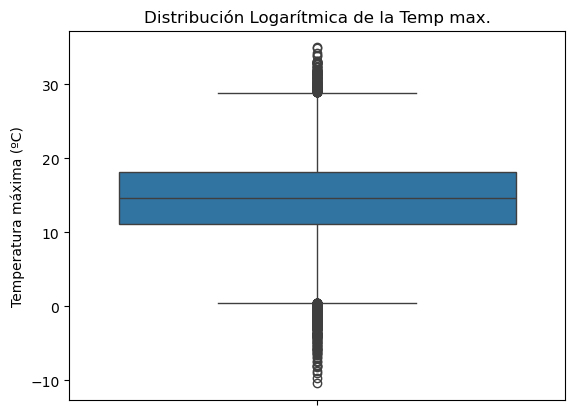

In [11]:
df_aemet["Temperatura máxima (ºC)"] = pd.to_numeric(df_aemet["Temperatura máxima (ºC)"].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)

sns.boxplot(df_aemet["Temperatura máxima (ºC)"]) 
plt.title("Distribución Logarítmica de la Temp max.")
plt.show()

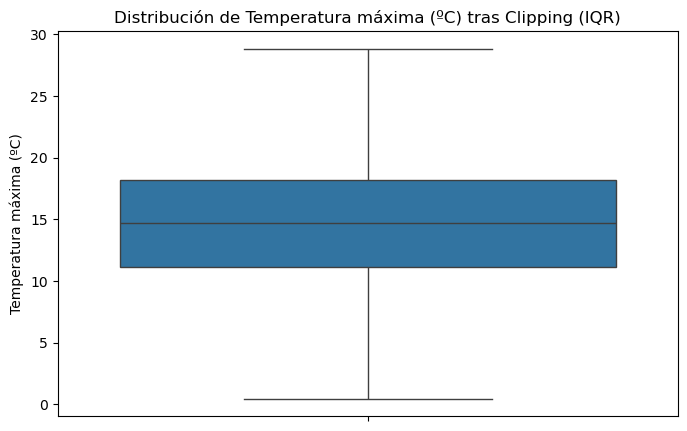

In [12]:
col = "Temperatura máxima (ºC)"

Q1 = df_aemet[col].quantile(0.25)
Q3 = df_aemet[col].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_aemet[col] = df_aemet[col].clip(lower=lower_limit, upper=upper_limit)


plt.figure(figsize=(8, 5))
sns.boxplot(y=df_aemet[col])
plt.title(f"Distribución de {col} tras Clipping (IQR)")
plt.show()

## Tratamiento Temperatura mínima

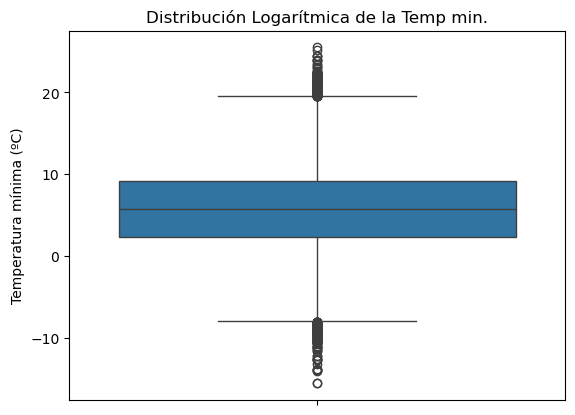

In [13]:
df_aemet["Temperatura mínima (ºC)"] = pd.to_numeric(df_aemet["Temperatura mínima (ºC)"].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)

sns.boxplot(df_aemet["Temperatura mínima (ºC)"]) 
plt.title("Distribución Logarítmica de la Temp min.")
plt.show()

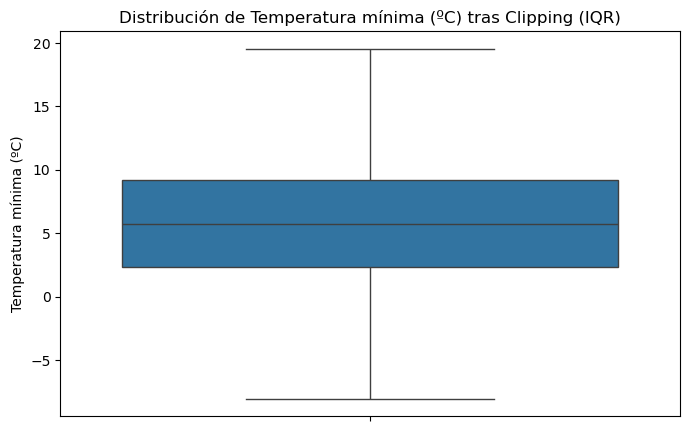

In [14]:
col = "Temperatura mínima (ºC)"

Q1 = df_aemet[col].quantile(0.25)
Q3 = df_aemet[col].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_aemet[col] = df_aemet[col].clip(lower=lower_limit, upper=upper_limit)


plt.figure(figsize=(8, 5))
sns.boxplot(y=df_aemet[col])
plt.title(f"Distribución de {col} tras Clipping (IQR)")
plt.show()

## Tratamiento Racha de viento

/opt/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


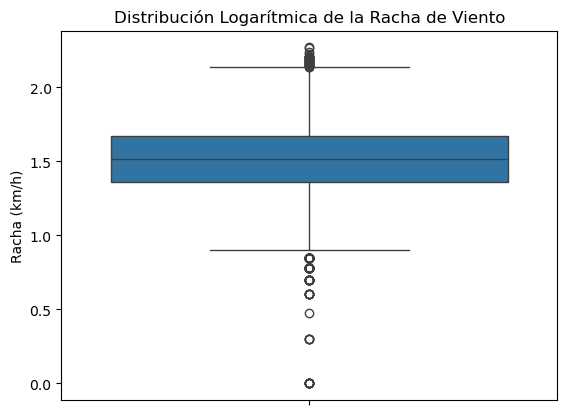

In [15]:
df_aemet["Racha (km/h)"] = df_aemet["Racha (km/h)"].fillna(0)
df_aemet["Racha (km/h)"] = pd.to_numeric(df_aemet["Racha (km/h)"].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)
df_aemet["Racha (km/h)"] = np.log10(df_aemet["Racha (km/h)"])

sns.boxplot(df_aemet["Racha (km/h)"]) 
plt.title("Distribución Logarítmica de la Racha de Viento")
plt.show()

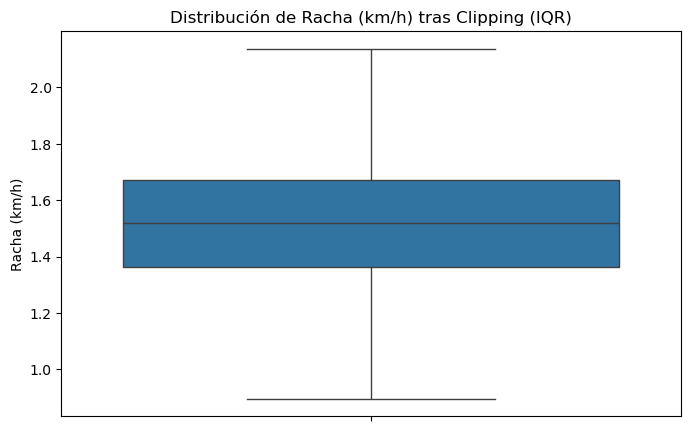

In [16]:
col = "Racha (km/h)"

Q1 = df_aemet[col].quantile(0.25)
Q3 = df_aemet[col].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_aemet[col] = df_aemet[col].clip(lower=lower_limit, upper=upper_limit)


plt.figure(figsize=(8, 5))
sns.boxplot(y=df_aemet[col])
plt.title(f"Distribución de {col} tras Clipping (IQR)")
plt.show()

## Tratamiento Velocidad máxima (km/h)

/opt/conda/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


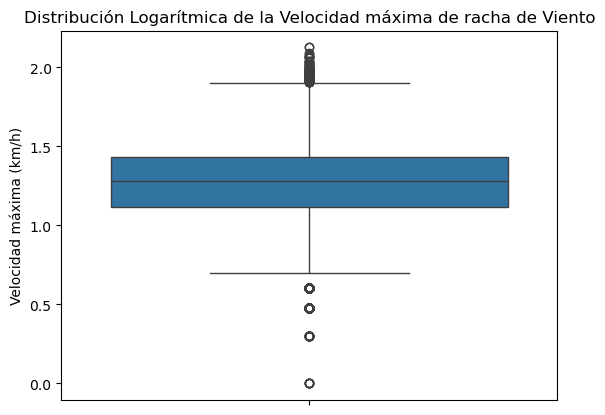

In [17]:

df_aemet["Velocidad máxima (km/h)"] = df_aemet["Velocidad máxima (km/h)"].fillna(0)
df_aemet["Velocidad máxima (km/h)"] = pd.to_numeric(df_aemet["Velocidad máxima (km/h)"].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)
df_aemet["Velocidad máxima (km/h)"] = np.log10(df_aemet["Velocidad máxima (km/h)"])

sns.boxplot(df_aemet["Velocidad máxima (km/h)"]) 
plt.title("Distribución Logarítmica de la Velocidad máxima de racha de Viento")
plt.show()

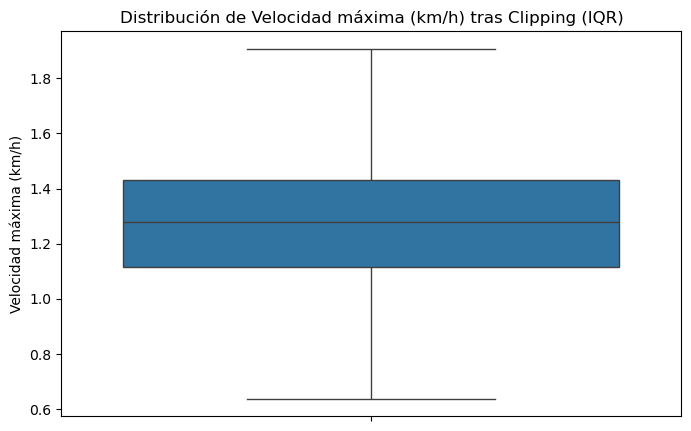

In [18]:
col = "Velocidad máxima (km/h)"

Q1 = df_aemet[col].quantile(0.25)
Q3 = df_aemet[col].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_aemet[col] = df_aemet[col].clip(lower=lower_limit, upper=upper_limit)


plt.figure(figsize=(8, 5))
sns.boxplot(y=df_aemet[col])
plt.title(f"Distribución de {col} tras Clipping (IQR)")
plt.show()

In [19]:
df_aemet.head()

,Estación,Provincia,Temperatura máxima (ºC),Temperatura mínima (ºC),Temperatura media (ºC),Racha (km/h),Velocidad máxima (km/h),Precipitación 00-24h (mm),Precipitación 00-06h (mm),Precipitación 06-12h (mm),Precipitación 12-18h (mm),Precipitación 18-24h (mm),fecha
0,Alforja,Tarragona,14.7,5.2,9.9,1.278754,1.000000,0.0,0.0,0.0,0.0,0.0,2026-03-01
1,Reus Aeropuerto,Tarragona,17.3,8.7,13.0,1.414973,1.230449,0.0,0.0,0.0,0.0,0.0,2026-03-01
3,Tarragona,Tarragona,16.1,10.2,13.2,1.255273,0.954243,0.2,0.2,0.0,0.0,0.0,2026-03-01
4,Pontons,Barcelona,12.9,4.6,8.7,1.477121,1.322219,0.0,0.0,0.0,0.0,0.0,2026-03-01
5,Vilafranca del Penedès,Barcelona,18.3,9.2,13.7,1.414973,1.113943,0.0,0.0,0.0,0.0,0.0,2026-03-01


# Limpieza festivos

En este df hay dias festivos NACIONALES, no se incluyen los dias festivos que hay en cada comunidad autonoma 

In [20]:
df_festivos.head()

,fecha,tipo_dia
0,2024-01-01,Festivo
1,2024-01-02,Laboral
2,2024-01-03,Laboral
3,2024-01-04,Laboral
4,2024-01-05,Laboral


In [21]:
df_festivos['tipo_dia'].value_counts()


tipo_dia
Laboral          763
Fin de semana    307
Festivo           26
Name: count, dtype: int64

# Limpieza ESIOS

In [22]:
df_esios.head()

,tipo de energia,valor,porcentaje,fecha
0,Hidráulica,76727.058,0.174197,2026-01-11T00:00:00.000+01:00
1,Hidráulica,94637.830,0.219888,2026-01-12T00:00:00.000+01:00
2,Hidráulica,119453.328,0.261347,2026-01-13T00:00:00.000+01:00
3,Hidráulica,140690.056,0.435588,2026-01-14T00:00:00.000+01:00
4,Hidráulica,111567.551,0.267968,2026-01-15T00:00:00.000+01:00


In [23]:
df_esios = df_esios.sort_values('fecha',ascending=False)
if 'fecha' in df_esios.columns:
    df_esios['fecha'] = pd.to_datetime(df_esios['fecha'], utc=True)

In [24]:
df_esios['porcentaje'] = (pd.to_numeric(df_esios['porcentaje'], errors='coerce') * 100).round(2)
df_esios['fecha'] = pd.to_datetime(df_esios['fecha'], utc=True).dt.strftime('%Y-%m-%d')

df_esios.head()

,tipo de energia,valor,porcentaje,fecha
257,Eólica,95855.7,20.30,2026-05-18
128,Hidráulica,95855.7,20.30,2026-05-18
127,Hidráulica,98766.5,22.34,2026-05-17
256,Eólica,98766.5,22.34,2026-05-17
126,Hidráulica,89000.1,22.79,2026-05-16


In [25]:
# Guardar el DataFrame de la AEMET
df_aemet.to_parquet('datos_aemet.parquet', index=False)

# Guardar el DataFrame de la AEMET
df_festivos.to_parquet('datos_festivos.parquet', index=False)

# Guardar el DataFrame de ESIOS
df_esios.to_parquet('datos_esios.parquet', index=False)

# Carga de datos en HDFS

Instalamos HDFS en el entorno

`%pip install hdfs`

He tenido que conectar el contenedor de Jupyter con el contenedor de HDFS

`docker network connect proyectofinal_default jupyter_datascience`

In [26]:
client = InsecureClient('http://namenode:9870', user='root')

archivos_a_subir = [
    ('/datalake/plata/clima/datos_aemet.parquet', 'datos_aemet.parquet'),
    ('/datalake/plata/consumo/datos_esios.parquet', 'datos_esios.parquet'),
    ('/datalake/plata/festivos/datos_festivos.parquet', 'datos_festivos.parquet')
]

for ruta_hdfs, archivo_local in archivos_a_subir:
    print(f"Procesando: {archivo_local}...")
    
    if client.status(ruta_hdfs, strict=False):
        print(f"  - El archivo ya existe en '{ruta_hdfs}'. Procediendo a borrarlo...")
        client.delete(ruta_hdfs)
        print("  - Archivo antiguo borrado con éxito.")
    
    directorio_hdfs = os.path.dirname(ruta_hdfs)
    client.makedirs(directorio_hdfs)
    
    client.upload(ruta_hdfs, archivo_local)
    print(f"  - ¡Nuevo archivo '{archivo_local}' subido correctamente!\n")

print("¡Todos los archivos han sido procesados y subidos a HDFS!")

Procesando: datos_aemet.parquet...
  - El archivo ya existe en '/datalake/plata/clima/datos_aemet.parquet'. Procediendo a borrarlo...
  - Archivo antiguo borrado con éxito.
  - ¡Nuevo archivo 'datos_aemet.parquet' subido correctamente!

Procesando: datos_esios.parquet...
  - El archivo ya existe en '/datalake/plata/consumo/datos_esios.parquet'. Procediendo a borrarlo...
  - Archivo antiguo borrado con éxito.
  - ¡Nuevo archivo 'datos_esios.parquet' subido correctamente!

Procesando: datos_festivos.parquet...
  - El archivo ya existe en '/datalake/plata/festivos/datos_festivos.parquet'. Procediendo a borrarlo...
  - Archivo antiguo borrado con éxito.
  - ¡Nuevo archivo 'datos_festivos.parquet' subido correctamente!

¡Todos los archivos han sido procesados y subidos a HDFS!
